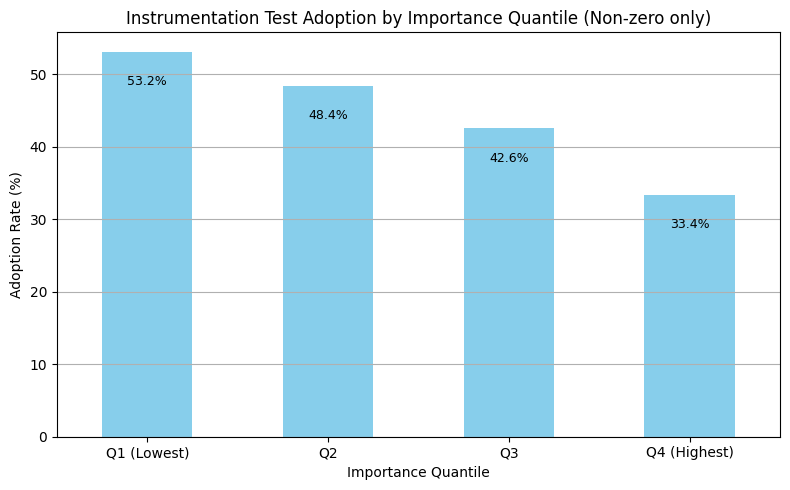

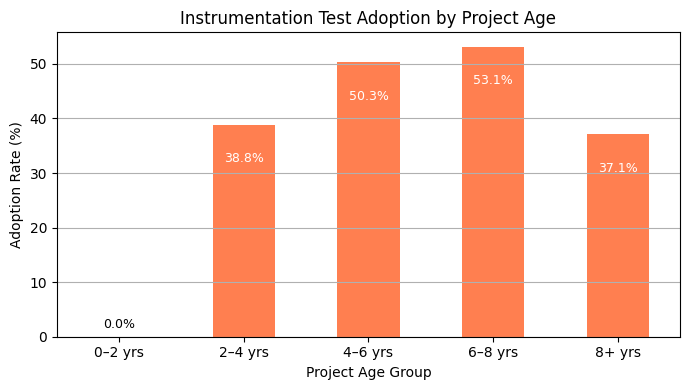

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# === Load the dataset ===
file_path = r"F:\Android_Mobile_App\AndroidProject_2nd\Analysis Output\7.4-Total_Repos_WithMetrics.csv"
df = pd.read_csv(file_path)

# === Ensure columns are correctly typed ===
df["Instrumentation_Test(Local or CI)"] = df["Instrumentation_Test(Local or CI)"].astype(bool)
df["Unit_Test(Local or CI)"] = df["Unit_Test(Local or CI)"].astype(bool)

# === Compute importance score ===
df["importance_score"] = df[["stars", "forks", "contributors"]].fillna(0).sum(axis=1)

# === Filter out zero importance rows ===
df_nonzero = df[df["importance_score"] > 0].copy()
df_nonzero.loc[:, "importance_quantile"] = pd.qcut(
    df_nonzero["importance_score"],
    q=4,
    labels=["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"]
)

# === Create quantile bins ===
df_nonzero["importance_quantile"] = pd.qcut(
    df_nonzero["importance_score"],
    q=4,
    labels=["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"]
)

# === Compute mean adoption rate by quantile ===
summary = df_nonzero.groupby("importance_quantile",observed=False)[
    ["Instrumentation_Test(Local or CI)", "Unit_Test(Local or CI)"]
].mean() * 100

# === Plot the instrumentation test adoption ===
plt.figure(figsize=(8, 5))
ax= summary["Instrumentation_Test(Local or CI)"].plot(kind='bar', color='skyblue')
plt.title("Instrumentation Test Adoption by Importance Quantile (Non-zero only)")
plt.ylabel("Adoption Rate (%)")
plt.xlabel("Importance Quantile")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()

# === Add value labels ===
for i, value in enumerate(summary["Instrumentation_Test(Local or CI)"]):
    ax.text(i, value - 5, f"{value:.1f}%", ha='center', va='bottom', fontsize=9)

plt.show()


#=========== comparing test adoption vs age =========================

# === Convert and sanitize datetime ===
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce").dt.tz_localize(None)

# === Filter valid dates ===
df_age = df.dropna(subset=["created_at"]).copy()

# === Calculate project age in years ===
df_age["project_age_years"] = (pd.Timestamp("2025-06-11") - df_age["created_at"]).dt.days / 365.25

# === Bin into age ranges ===
df_age["age_group"] = pd.cut(
    df_age["project_age_years"],
    bins=[0, 2, 4, 6, 8, 20],
    labels=["0–2 yrs", "2–4 yrs", "4–6 yrs", "6–8 yrs", "8+ yrs"]
)

# === Calculate average adoption per age group ===
age_vs_testing = df_age.groupby("age_group",observed=False)[
    ["Instrumentation_Test(Local or CI)", "Unit_Test(Local or CI)"]
].mean() * 100

# === Plot instrumentation testing adoption ===
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
ax = age_vs_testing["Instrumentation_Test(Local or CI)"].plot(kind='bar', color='coral')
plt.title("Instrumentation Test Adoption by Project Age")
plt.ylabel("Adoption Rate (%)")
plt.xlabel("Project Age Group")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()

# === Add value labels with condition for zero bars ===
for i, value in enumerate(age_vs_testing["Instrumentation_Test(Local or CI)"]):
    if value == 0:
        ax.text(i, 1, "0.0%", ha='center', va='bottom', fontsize=9, color='black')  # Lift it just above the x-axis
    else:
        ax.text(i, value - 5, f"{value:.1f}%", ha='center', va='top', fontsize=9, color='white')

plt.show()
